<a href="https://colab.research.google.com/github/silviolima07/desafio_final/blob/main/desafio_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv('/content/dataset_final.csv')

In [3]:
df.head()

,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda,idade_carro
0,Nissan,Frontier,2000,117290,Cinza,Manual,Gasolina,4,43413.0,26
1,Ford,Ranger,2000,141406,Preto,Manual,Flex,4,33267.8,26
2,Toyota,Hilux,2000,138468,Branco,Manual,Flex,2,51867.4,26
3,Renault,Sandero,2000,105311,Azul,Manual,Gasolina,2,22289.8,26
4,Renault,Duster,2000,31654,Prata,Automático,Diesel,2,35878.2,26


### Aplicar onehotencoder nas colunas categoricas

In [7]:
colunas = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']

In [8]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(df[colunas])

# Create a DataFrame with the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(colunas))

# Concatenate the original DataFrame with the new encoded features, dropping the original categorical columns
df_encoded = pd.concat([df.drop(columns=colunas), encoded_df], axis=1)

# Display the first few rows of the new DataFrame
display(df_encoded.head())

,Ano,Quilometragem,Portas,Valor_Venda,idade_carro,Marca_Chevrolet,Marca_Fiat,Marca_Ford,Marca_Honda,Marca_Hyundai,...,Cor_Branco,Cor_Cinza,Cor_Prata,Cor_Preto,Cor_Vermelho,Cambio_Automático,Cambio_Manual,Combustivel_Diesel,Combustivel_Flex,Combustivel_Gasolina
0,2000,117290,4,43413.0,26,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2000,141406,4,33267.8,26,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2000,138468,2,51867.4,26,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,2000,105311,2,22289.8,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,2000,31654,2,35878.2,26,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


### Dividir dados em treino e teste

In [72]:
X = df_encoded.drop(columns=['Valor_Venda'])
y = df_encoded['Valor_Venda']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 57)
Treino (80%): (7748, 57)
Teste (20%): (1938, 57)


### Modelos a serem treinados e avaliados:
- RandomForestRegressor
- LGBMRegressor


### Função para treinar e avaliar modelos

In [74]:
def train_and_evaluate_model(model_obj, model_name, X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_feature, lista_total_features):
    """
    Treina e avalia um modelo de regressão.

    Args:
        model_obj: O objeto do modelo a ser treinado (e.g., RandomForestRegressor, LGBMRegressor).
        model_name (str): O nome do modelo (para identificação nos resultados).
        X_train (pd.DataFrame): Dados de treino (features).
        y_train (pd.Series): Target de treino.
        X_test (pd.DataFrame): Dados de teste (features).
        y_test (pd.Series): Target de teste.
        feature_cols (list): Nomes das colunas de features.
        lista_modelo (list): Lista para armazenar os nomes dos modelos avaliados.
        lista_r2 (list): Lista para armazenar as métricas R² dos modelos.
        lista_mae (list): Lista para armazenar as métricas MAE dos modelos.
        lista_feature (list): Lista para armazenar a importância das features de cada modelo.
        lista_total_features (list): Lista para armazenar o total de features usadas em cada modelo.
    """
    print(f"\n--- Treinando e avaliando: {model_name} ---")

    # Treinar modelo
    model_obj.fit(X_train, y_train)

    # Fazer previsões
    y_pred = model_obj.predict(X_test)

    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"R²: {r2:.4f}")
    print(f"MAE : {mae:.2f} mg/dL")

    # Armazenar resultados
    lista_modelo.append(model_name)
    lista_r2.append(r2)
    lista_mae.append(mae)

    # Armazenar total de features usadas
    lista_total_features.append(len(feature_cols))

    # Importância das features
    if hasattr(model_obj, 'feature_importances_'):
        importancias = pd.DataFrame({
            'feature': feature_cols,
            'importancia': model_obj.feature_importances_
        }).sort_values('importancia', ascending=False)
        lista_feature.append(importancias)
        print("\nTop 10 features mais importantes:")
        display(importancias.head(10).reset_index(drop=True))
    else:
        print("Modelo não possui atributo feature_importances_.")
        lista_feature.append(None)


# Modificar a célula existente para usar a função


In [75]:
# Inicializar listas para armazenamento de resultados
lista_modelo = []
lista_r2 = []
lista_mae = []
lista_total_features = []
lista_feature = []

feature_cols = X.columns

# Definir os modelos
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_lgb = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    verbose=-1 # Suprime a saída verbosa durante o treinamento
)

# Chamar a função para cada modelo
train_and_evaluate_model(model_rf, "RandomForestRegressor", X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_feature, lista_total_features)
train_and_evaluate_model(model_lgb, "LGBMRegressor", X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_feature, lista_total_features)

# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'Total de Features': lista_total_features
})
display(resultados_df)


--- Treinando e avaliando: RandomForestRegressor ---
R²: 0.9713
MAE : 2858.36 mg/dL

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.315527
1,Marca_Jeep,0.186922
2,idade_carro,0.129239
3,Ano,0.109210
4,Marca_Toyota,0.102242
5,Marca_Honda,0.088400
6,Marca_Nissan,0.031703
7,Marca_Ford,0.016228
8,Marca_Hyundai,0.004481
9,Marca_Renault,0.001289



--- Treinando e avaliando: LGBMRegressor ---
R²: 0.9748
MAE : 2695.30 mg/dL

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,841
1,Ano,647
2,Marca_Toyota,130
3,Marca_Jeep,125
4,Marca_Honda,122
5,Marca_Fiat,98
6,Marca_Renault,96
7,Marca_Volkswagen,94
8,Marca_Nissan,93
9,Marca_Ford,82



--- Resumo das Avaliações ---


,Modelo,R²,MAE,Total de Features
0,RandomForestRegressor,0.971319,2858.364309,57
1,LGBMRegressor,0.974766,2695.303150,57


### Selecionar as 5 e 10 melhores features e retreinar o melhor modelo.
### Avaliar novamente.

In [81]:
#features_5 = ['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda']
#
features_10 = ['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda', 'Marca_Fiat', 'Marca_Renault', 'Marca_Volkswagen', 'Marca_Nissan', 'Marca_Ford']

In [82]:
X = df_encoded[features_10]
y = df_encoded['Valor_Venda']

In [83]:
X.columns, X.shape, y.shape

(Index(['Quilometragem', 'Ano', 'Marca_Toyota', 'Marca_Jeep', 'Marca_Honda',
        'Marca_Fiat', 'Marca_Renault', 'Marca_Volkswagen', 'Marca_Nissan',
        'Marca_Ford'],
       dtype='object'),
 (9686, 10),
 (9686,))

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% para treino
#
print("X:", X.shape)
print("Treino (80%):",X_train.shape)
print("Teste (20%):",X_test.shape)

X: (9686, 10)
Treino (80%): (7748, 10)
Teste (20%): (1938, 10)


In [85]:
feature_cols = X.columns

# Definir os modelos
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_lgb = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    verbose=-1 # Suprime a saída verbosa durante o treinamento
)

# Chamar a função para cada modelo
train_and_evaluate_model(model_rf, "RandomForestRegressor", X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_feature, lista_total_features)
train_and_evaluate_model(model_lgb, "LGBMRegressor", X_train, y_train, X_test, y_test, feature_cols, lista_modelo, lista_r2, lista_mae, lista_feature, lista_total_features)

# Exibir um resumo das métricas (opcional, após todos os modelos serem avaliados)
print("\n--- Resumo das Avaliações ---")
resultados_df = pd.DataFrame({
    'Modelo': lista_modelo,
    'R²': lista_r2,
    'MAE': lista_mae,
    'Total de Features': lista_total_features
})
resultados_df.sort_values(by=['R²'], ascending=[False], inplace=True)
display(resultados_df)


--- Treinando e avaliando: RandomForestRegressor ---
R²: 0.9681
MAE : 2970.63 mg/dL

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,0.326136
1,Ano,0.241154
2,Marca_Jeep,0.186922
3,Marca_Toyota,0.102242
4,Marca_Honda,0.088400
5,Marca_Nissan,0.031703
6,Marca_Ford,0.016235
7,Marca_Renault,0.003382
8,Marca_Fiat,0.002364
9,Marca_Volkswagen,0.001461



--- Treinando e avaliando: LGBMRegressor ---
R²: 0.9747
MAE : 2694.28 mg/dL

Top 10 features mais importantes:


,feature,importancia
0,Quilometragem,1214
1,Ano,796
2,Marca_Toyota,173
3,Marca_Honda,165
4,Marca_Jeep,159
5,Marca_Nissan,146
6,Marca_Ford,120
7,Marca_Renault,88
8,Marca_Fiat,76
9,Marca_Volkswagen,63



--- Resumo das Avaliações ---


,Modelo,R²,MAE,Total de Features
1,LGBMRegressor,0.974766,2695.303150,57
5,LGBMRegressor,0.974726,2694.281774,10
0,RandomForestRegressor,0.971319,2858.364309,57
4,RandomForestRegressor,0.968103,2970.633237,10
3,LGBMRegressor,0.910404,4913.097591,5
2,RandomForestRegressor,0.886297,5404.600649,5


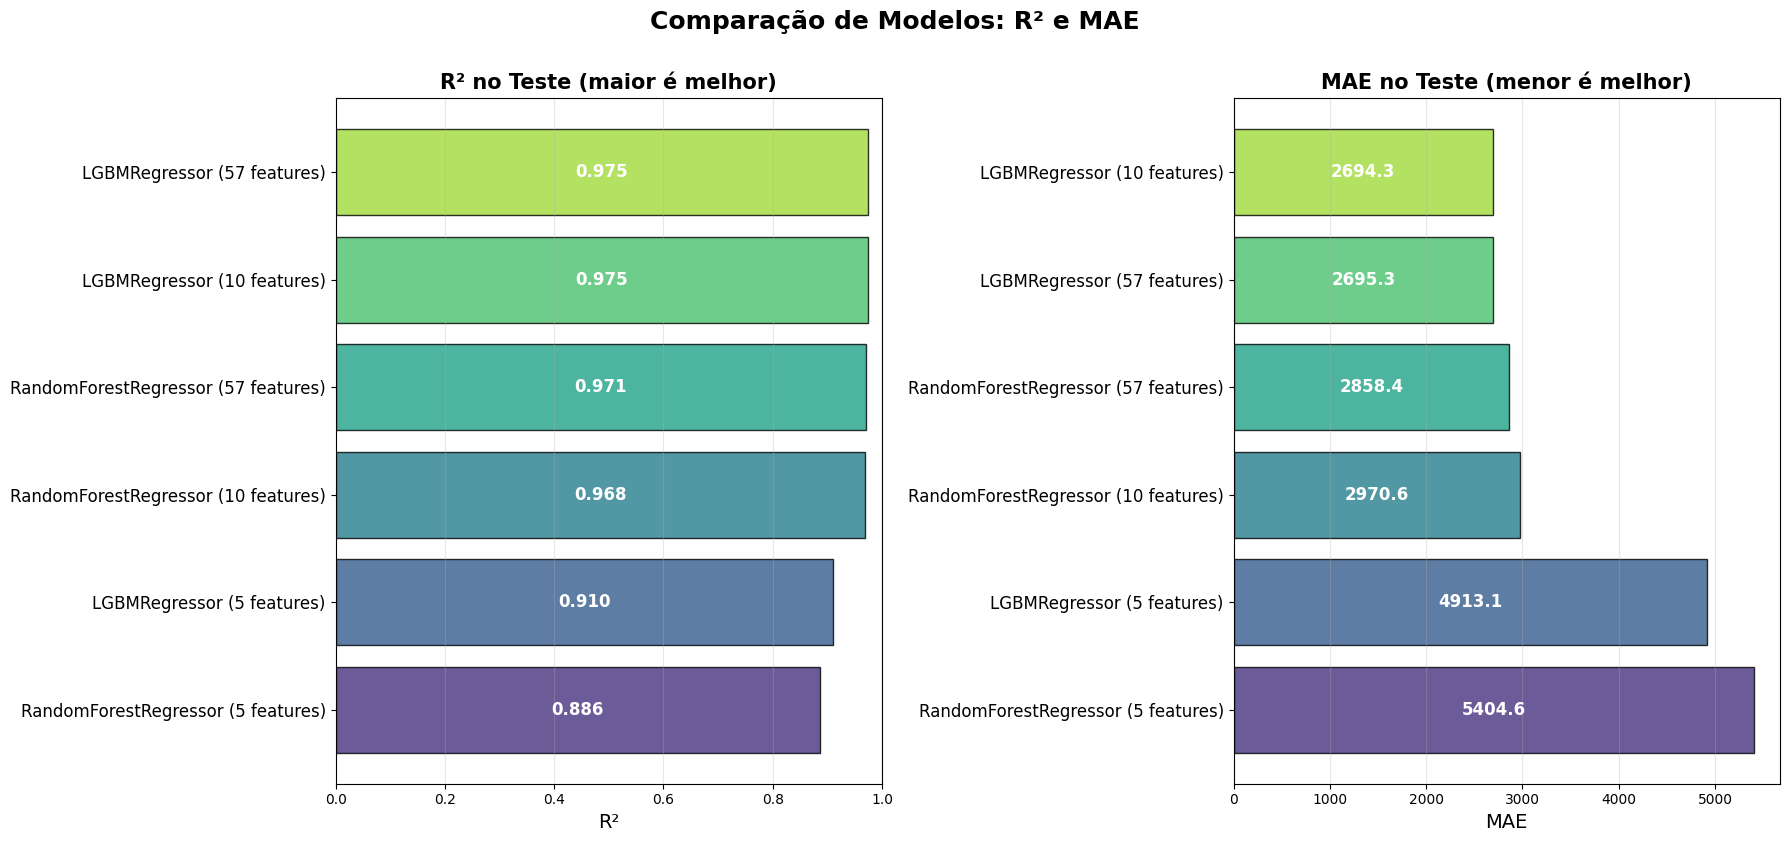

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar o DataFrame de resultados já existente
resultados = resultados_df.copy()

# Criar um rótulo mais descritivo para incluir o número de features
resultados['Modelo_Features'] = resultados['Modelo'] + ' (' + resultados['Total de Features'].astype(str) + ' features)'

# Criar figura com 1 linha e 2 colunas para os 2 plots horizontais (R² e MAE)
fig, axes = plt.subplots(1, 2, figsize=(18, 9)) # Ajustar tamanho da figura
fig.suptitle('Comparação de Modelos: R² e MAE', fontsize=18, fontweight='bold')

# 1. R² Comparativo
ax = axes[0]
# Sort for R² plot (descending R²)
r_squared_sorted = resultados.sort_values(by=['R²'], ascending=True)
bars = ax.barh(r_squared_sorted['Modelo_Features'], r_squared_sorted['R²'],
              color=sns.color_palette('viridis', n_colors=len(r_squared_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('R²', fontsize=14)
ax.set_title('R² no Teste (maior é melhor)', fontsize=15, fontweight='bold')
ax.set_xlim([0, 1]) # Limite para o eixo X (R²)
ax.grid(True, alpha=0.3, axis='x') # Grid no eixo X para barras horizontais
ax.tick_params(axis='y', labelsize=12) # Rótulos no eixo Y

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, r_squared_sorted['R²']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.3f}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)

# 2. MAE Comparativo
ax = axes[1]
# Sort for MAE plot (ascending MAE)
mae_sorted = resultados.sort_values(by=['MAE'], ascending=False)
bars = ax.barh(mae_sorted['Modelo_Features'], mae_sorted['MAE'],
              color=sns.color_palette('viridis', n_colors=len(mae_sorted)), alpha=0.8, edgecolor='black', linewidth=1)
ax.set_xlabel('MAE', fontsize=14)
ax.set_title('MAE no Teste (menor é melhor)', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.tick_params(axis='y', labelsize=12)

# Adicionar valores DENTRO das barras
for bar, valor in zip(bars, mae_sorted['MAE']):
    width = bar.get_width()
    ax.text(width / 2, bar.get_y() + bar.get_height()/2.,
            f'{valor:.1f}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.97]) # Ajustar layout para título superior
plt.show()

### GridSearch

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
])

param_grid = {
    'lgbm__n_estimators': [100, 200, 300],
    'lgbm__learning_rate': [0.05, 0.1, 0.2],
    'lgbm__num_leaves': [10, 20, 31, 40],
    'lgbm__max_depth': [5, 10, -1] # -1 means no limit
}

In [97]:
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

In [98]:
print("Treinando o modelo e buscando os melhores parametros")
grid.fit(X_train, y_train)

print("\nGridSearch\n Melhores parâmetros:", grid.best_params_)
print("\nMelhor score CV:", grid.best_score_)
print("Total Features:", len(X_train.columns))
#
best_model = grid.best_estimator_

test_score = best_model.score(X_test, y_test)
print("R2 no teste:", round(test_score,4))
y_pred_test = best_model.predict(X_test)
print(f"MAE teste : {mean_absolute_error(y_test, y_pred_test):.2f}")

Treinando o modelo e buscando os melhores parametros
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearch
 Melhores parâmetros: {'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 300, 'lgbm__num_leaves': 20}

Melhor score CV: 0.9747680833416676
Total Features: 10
R2 no teste: 0.9749
MAE teste : 2695.93


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Modificando a Pipeline para Preservar Nomes das Features

In [103]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor

# Modificando a pipeline para usar set_output(transform="pandas")
pipeline_no_warning = Pipeline([
    ('scaler', StandardScaler().set_output(transform="pandas")),
    ('lgbm', LGBMRegressor(random_state=42, verbose=-1))
])

param_grid = {
    'lgbm__n_estimators': [200, 300, 400],
    'lgbm__learning_rate': [0.05, 0.1, 0.2],
    'lgbm__num_leaves': [10, 20, 30],
    'lgbm__max_depth': [5, 10, -1]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_no_warning = GridSearchCV(
    pipeline_no_warning,
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Treinando o modelo.")
grid_no_warning.fit(X_train, y_train)

print("\nGridSearch - Melhores parâmetros :", grid_no_warning.best_params_)
print("\nMelhor score CV (sem warnings):", grid_no_warning.best_score_)
print("Total Features:", len(X_train.columns))

best_model_no_warning = grid_no_warning.best_estimator_

test_score_no_warning = best_model_no_warning.score(X_test, y_test)
print("R2 no teste (sem warnings):", round(test_score_no_warning,4))
y_pred_test_no_warning = best_model_no_warning.predict(X_test)
print(f"MAE teste (sem warnings) : {mean_absolute_error(y_test, y_pred_test_no_warning):.2f}")

Treinando o modelo.
Fitting 5 folds for each of 81 candidates, totalling 405 fits

GridSearch - Melhores parâmetros : {'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 400, 'lgbm__num_leaves': 10}

Melhor score CV (sem warnings): 0.9749252435773397
Total Features: 10
R2 no teste (sem warnings): 0.9743
MAE teste (sem warnings) : 2730.64


In [105]:
# Treinar modelo com os melhores parametros identificados
params = grid_no_warning.best_params_
print('\nGridSearch - Best params:\n', grid_no_warning.best_params_)

cleaned_params = {key.replace('lgbm__', ''): value for key, value in params.items()}

model = LGBMRegressor(**cleaned_params, random_state = 42, verbose=-1)

model.fit(X_train, y_train)

# Avaliar
y_pred_test = model.predict(X_test)

print("\nAvaliacao Final\n\nModelo LGBMRegressor")
print("Total Features:", len(X_train.columns))
r2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2:.4f}")
print(f"MAE test : {mean_absolute_error(y_test, y_pred_test):.2f}")


GridSearch - Best params:
 {'lgbm__learning_rate': 0.05, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 400, 'lgbm__num_leaves': 10}

Avaliacao Final

Modelo LGBMRegressor
Total Features: 10
R² test: 0.9745
MAE test : 2715.40
